# Hate Speech Classification using RNN, LSTM, and Word2Vec

**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Group:** L6CG03  
**Tutor:** Mr. Shiv Kumar Yadav

This notebook implements the Language Task (Part III) of the Final Portfolio Assessment.  
It covers binary classification of tweets as racist/sexist or not, using:

- **Model 1:** Simple RNN with trainable Embedding layer
- **Model 2:** LSTM with trainable Embedding layer
- **Model 3:** LSTM with pretrained GloVe (Word2Vec-style) embeddings
- **Bonus:** Gradio GUI for real-time prediction

> **Recommended runtime:** Google Colab → *Runtime ▸ Change runtime type ▸ T4 GPU*.

> **Important note:** This dataset has severe class imbalance (~93% non-hate / 7% hate). We will track per-class F1-score and use class weighting during training.


## 1. Setup and Imports

In [1]:
# Install gensim if not present (Colab note: numpy compatibility may be needed)
# Uncomment and run if you hit gensim import errors:
# !pip install -q numpy==1.23.5
# !pip install -q gensim
# !pip install -q gradio

import os
import re
import time
import random
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version :', tf.__version__)
print('GPU available      :', tf.config.list_physical_devices('GPU'))


TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data Loading

Two ways to load — pick one and edit the path.

In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset (one-time, only if not already extracted)
import os
import zipfile

# Corrected ZIP_PATH to match the actual file name with spaces
ZIP_PATH = '/content/drive/MyDrive/Racist Sexist or Not Dataset-20260430T124857Z-3-001.zip'
EXTRACT_DIR = '/content/data'

if not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print(f'Extracted to {EXTRACT_DIR}')
else:
    print(f'Already extracted at {EXTRACT_DIR}')

# The CSV is inside a subfolder — point to it
TRAIN_PATH = '/content/data/7. Racist Sexist or Not Dataset/train_racisit.csv'

import pandas as pd
df = pd.read_csv(TRAIN_PATH)
print(f'Loaded {len(df)} rows')
print(f'Columns: {list(df.columns)}')
df.head()

Mounted at /content/drive
Extracted to /content/data
Loaded 31962 rows
Columns: ['id', 'label', 'tweet']


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## 3. Exploratory Data Analysis

In [3]:
print('Shape:', df.shape)
print('\nMissing values:', df.isnull().sum().sum())
print('\nClass distribution:')
print(df['label'].value_counts())
print('\nClass percentages:')
print((df['label'].value_counts(normalize=True) * 100).round(2))


Shape: (31962, 3)

Missing values: 0

Class distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Class percentages:
label
0    92.99
1     7.01
Name: proportion, dtype: float64


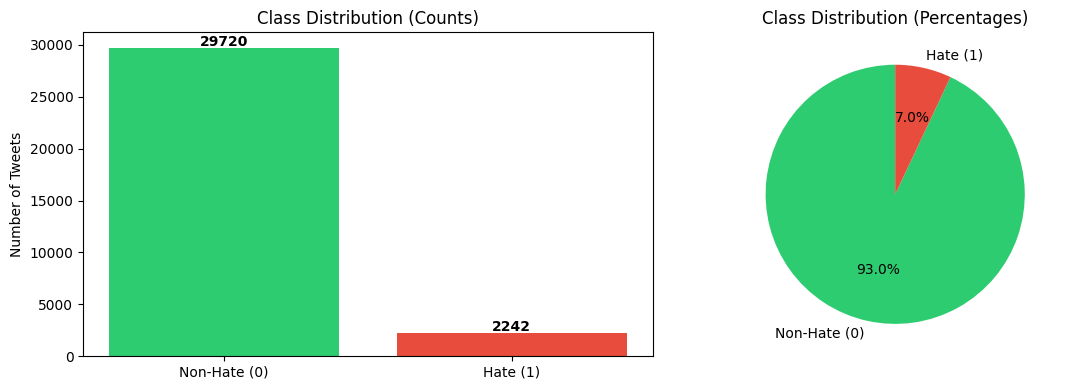


Observation: Severe class imbalance — only ~7% of tweets are labeled hate speech.
We will use class weights during training and prioritize F1-score over accuracy.


In [4]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts().sort_index()
labels = ['Non-Hate (0)', 'Hate (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title('Class Distribution (Counts)')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Percentages)')

plt.tight_layout()
plt.show()

print('\nObservation: Severe class imbalance — only ~7% of tweets are labeled hate speech.')
print('We will use class weights during training and prioritize F1-score over accuracy.')


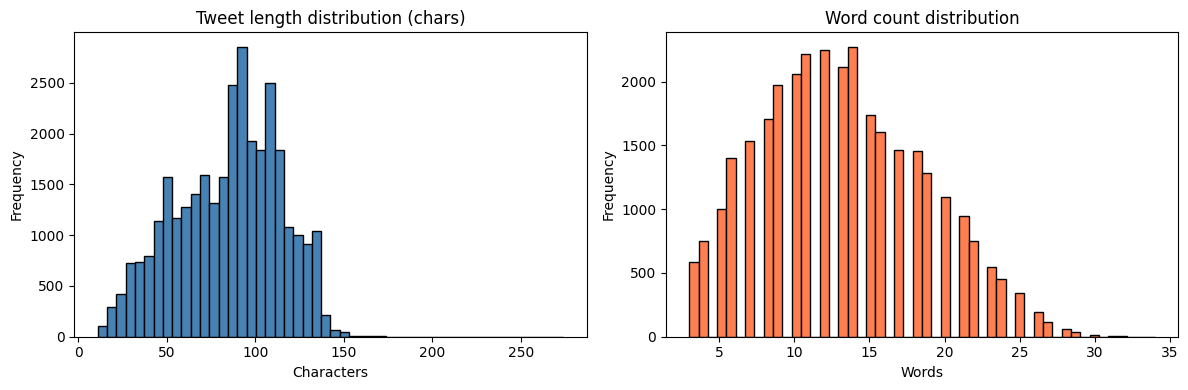

Tweet stats:
  Avg length:  85 chars
  Avg words:   13
  95th pct:    23 words


In [5]:
# Tweet length distribution
df['tweet_length'] = df['tweet'].str.len()
df['word_count'] = df['tweet'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['tweet_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Tweet length distribution (chars)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['word_count'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Word count distribution')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Tweet stats:")
print(f"  Avg length:  {df['tweet_length'].mean():.0f} chars")
print(f"  Avg words:   {df['word_count'].mean():.0f}")
print(f"  95th pct:    {df['word_count'].quantile(0.95):.0f} words")


In [6]:
# Sample tweets from each class
print('=== Sample NON-HATE tweets (label=0) ===')
for t in df[df['label']==0]['tweet'].head(3):
    print(f'  • {t.strip()}')

print('\n=== Sample HATE tweets (label=1) ===')
for t in df[df['label']==1]['tweet'].head(3):
    print(f'  • {t.strip()}')


=== Sample NON-HATE tweets (label=0) ===
  • @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
  • @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
  • bihday your majesty

=== Sample HATE tweets (label=1) ===
  • @user #cnn calls #michigan middle school 'build the wall' chant '' #tcot
  • no comment!  in #australia   #opkillingbay #seashepherd #helpcovedolphins #thecove  #helpcovedolphins
  • retweet if you agree!


## 4. Text Preprocessing

Pipeline: lowercase → expand contractions → remove URLs/mentions/hashtags/numbers/special chars → remove stopwords → lemmatize.

In [7]:
# Contraction map
CONTRACTIONS = {
    "ain't": 'is not', "aren't": 'are not', "can't": 'cannot',
    "could've": 'could have', "couldn't": 'could not',
    "didn't": 'did not', "doesn't": 'does not', "don't": 'do not',
    "hadn't": 'had not', "hasn't": 'has not', "haven't": 'have not',
    "he'd": 'he would', "he'll": 'he will', "he's": 'he is',
    "i'd": 'i would', "i'll": 'i will', "i'm": 'i am', "i've": 'i have',
    "isn't": 'is not', "it's": 'it is', "let's": 'let us',
    "shouldn't": 'should not', "that's": 'that is', "there's": 'there is',
    "they'd": 'they would', "they'll": 'they will', "they're": 'they are', "they've": 'they have',
    "we'd": 'we would', "we'll": 'we will', "we're": 'we are', "we've": 'we have',
    "weren't": 'were not', "what's": 'what is', "won't": 'will not',
    "wouldn't": 'would not', "you'd": 'you would', "you'll": 'you will',
    "you're": 'you are', "you've": 'you have',
}

STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def clean_tweet(text):
    """Clean a single tweet through the full preprocessing pipeline."""
    # 1. Lowercase
    text = text.lower()
    # 2. Expand contractions
    for c, full in CONTRACTIONS.items():
        text = text.replace(c, full)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 4. Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # 5. Remove hashtags (keep the word, drop the #)
    text = re.sub(r'#', '', text)
    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 7. Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 8. Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

# Sanity test on a sample
sample = df['tweet'].iloc[0]
print('Original:', sample)
print('Cleaned :', clean_tweet(sample))


Original:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
Cleaned : father dysfunctional selfish drag kid dysfunction run


In [8]:
# Apply cleaning to all tweets (takes ~30 seconds)
print('Cleaning tweets...')
df['cleaned'] = df['tweet'].apply(clean_tweet)

# Drop empty cleaned tweets
before = len(df)
df = df[df['cleaned'].str.len() > 0].reset_index(drop=True)
print(f'Removed {before - len(df)} empty tweets after cleaning')
print(f'Final dataset size: {len(df)}')

df[['tweet', 'cleaned', 'label']].head()


Cleaning tweets...
Removed 47 empty tweets after cleaning
Final dataset size: 31915


,tweet,cleaned,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cannot use cause offer whee...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,model love take time,0
4,factsguide: society now #motivation,factsguide society motivation,0


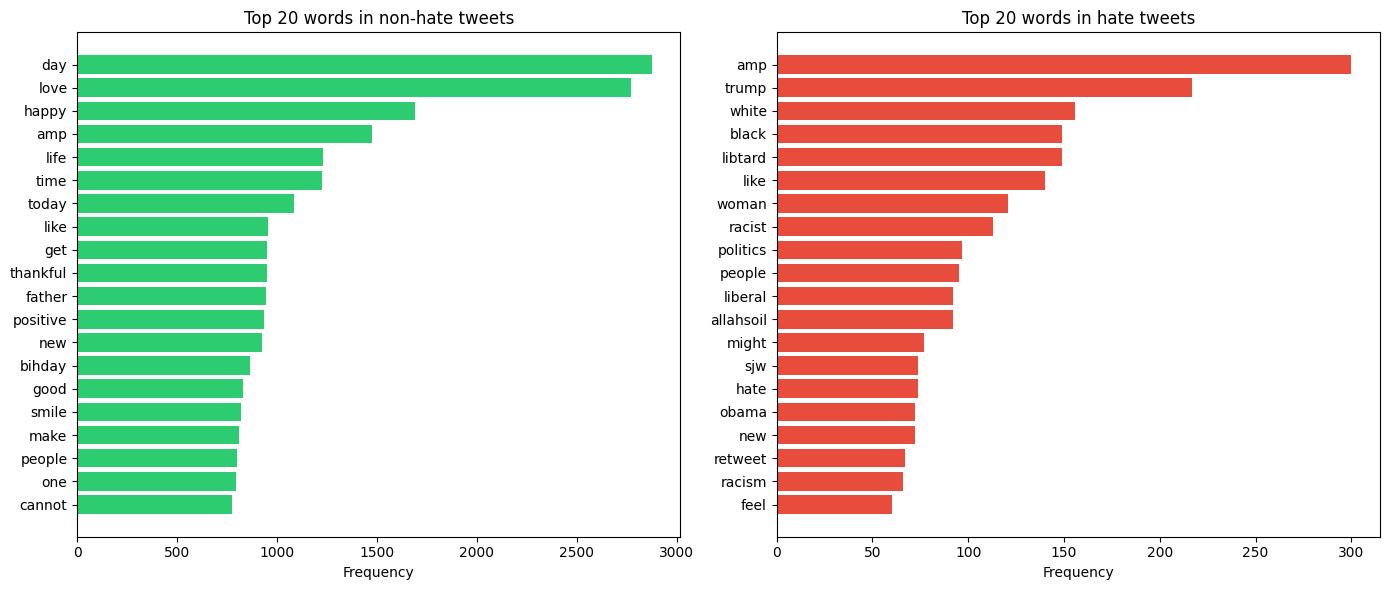

In [9]:
# Word frequency comparison between classes
from collections import Counter

hate_words = ' '.join(df[df['label']==1]['cleaned']).split()
nonhate_words = ' '.join(df[df['label']==0]['cleaned']).split()

top_hate = Counter(hate_words).most_common(20)
top_nonhate = Counter(nonhate_words).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh([w for w, c in top_nonhate[::-1]], [c for w, c in top_nonhate[::-1]], color='#2ecc71')
axes[0].set_title('Top 20 words in non-hate tweets')
axes[0].set_xlabel('Frequency')

axes[1].barh([w for w, c in top_hate[::-1]], [c for w, c in top_hate[::-1]], color='#e74c3c')
axes[1].set_title('Top 20 words in hate tweets')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()


## 5. Tokenization, Padding, and Train/Test Split

In [10]:
# 80/20 train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned'].values,
    df['label'].values,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label'].values  # Preserve class distribution
)

print(f'Train: {len(X_train_raw)} | Test: {len(X_test_raw)}')
print(f'Train label distribution: {np.bincount(y_train)}')
print(f'Test  label distribution: {np.bincount(y_test)}')


Train: 25532 | Test: 6383
Train label distribution: [23742  1790]
Test  label distribution: [5935  448]


In [11]:
# Tokenize — fit only on training data
VOCAB_SIZE = 10000  # cap vocabulary
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

# Percentile-based padding length (avoid being skewed by extreme outliers)
seq_lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f'Sequence length stats: mean={np.mean(seq_lengths):.1f}, max={max(seq_lengths)}')
print(f'95th percentile: {MAX_LEN} → using this as max length')

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nPadded shapes: train={X_train.shape}, test={X_test.shape}')
print(f'Vocab size used: {min(VOCAB_SIZE, len(tokenizer.word_index)+1)}')

# This is the actual vocab size after tokenizer cap
vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)


Sequence length stats: mean=7.5, max=20
95th percentile: 13 → using this as max length

Padded shapes: train=(25532, 13), test=(6383, 13)
Vocab size used: 10000


In [12]:
# Compute class weights for imbalance handling
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')
print('\n→ The minority class (hate=1) gets a higher weight, forcing the model to pay attention to it.')


Class weights: {0: np.float64(0.537696908432314), 1: np.float64(7.131843575418994)}

→ The minority class (hate=1) gets a higher weight, forcing the model to pay attention to it.


## 6. Helper Functions

In [13]:
def make_early_stopping():
    """Fresh callback for each model — avoids state leakage."""
    return callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
    )

def plot_history(history, title):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['loss'],     label='train')
    ax[0].plot(h['val_loss'], label='val')
    ax[0].set_title(f'{title} — loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(h['accuracy'],     label='train')
    ax[1].plot(h['val_accuracy'], label='val')
    ax[1].set_title(f'{title} — accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()

def evaluate_model(model, X_test, y_test, title):
    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_proba > 0.5).astype(int)

    print(f'\n===== {title} =====')
    print(classification_report(y_test, y_pred, target_names=['Non-Hate', 'Hate'], digits=3))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['Non-Hate', 'Hate'], yticklabels=['Non-Hate', 'Hate'],
                cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'{title} — Confusion Matrix')
    plt.tight_layout(); plt.show()

    return y_pred, y_proba


## 7. Model 1 — Simple RNN with Trainable Embedding

In [14]:
def build_simple_rnn(vocab_size, max_len, embed_dim=64):
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim),
        layers.SimpleRNN(64, dropout=0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ], name='simple_rnn')
    return model

rnn_model = build_simple_rnn(vocab_size, MAX_LEN)
rnn_model.summary()


Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_rnn = rnn_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[make_early_stopping()],
    verbose=1,
)
time_rnn = time.time() - t0
print(f'\nSimple RNN training time: {time_rnn:.1f} s')


Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7783 - loss: 0.4706 - val_accuracy: 0.9107 - val_loss: 0.2522
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9285 - loss: 0.1996 - val_accuracy: 0.8919 - val_loss: 0.2539
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9650 - loss: 0.0941 - val_accuracy: 0.9244 - val_loss: 0.2226
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9790 - loss: 0.0561 - val_accuracy: 0.9217 - val_loss: 0.3060
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9827 - loss: 0.0445 - val_accuracy: 0.8994 - val_loss: 0.3490
Epoch 6/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9879 - loss: 0.0314 - val_accuracy: 0.9190 - val_loss: 0.2623
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Simple RNN training time: 21.2 s


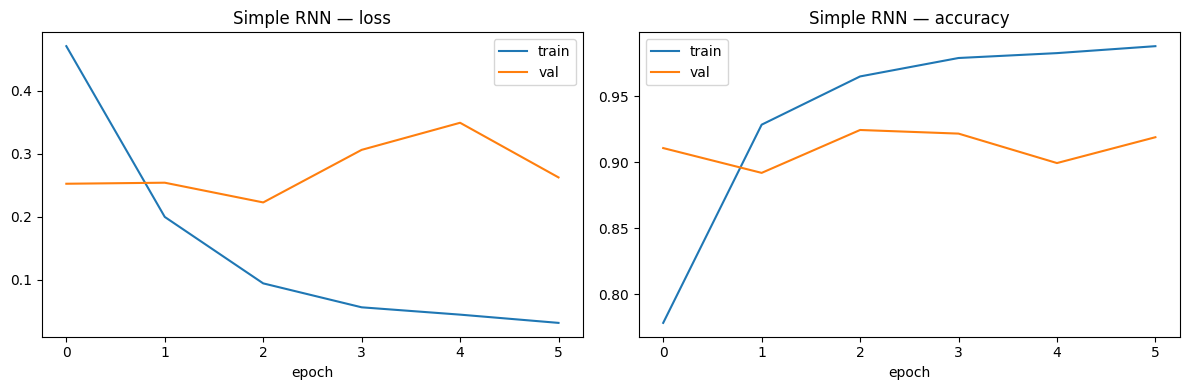


===== Simple RNN =====
              precision    recall  f1-score   support

    Non-Hate      0.981     0.933     0.956      5935
        Hate      0.462     0.759     0.574       448

    accuracy                          0.921      6383
   macro avg      0.721     0.846     0.765      6383
weighted avg      0.944     0.921     0.930      6383



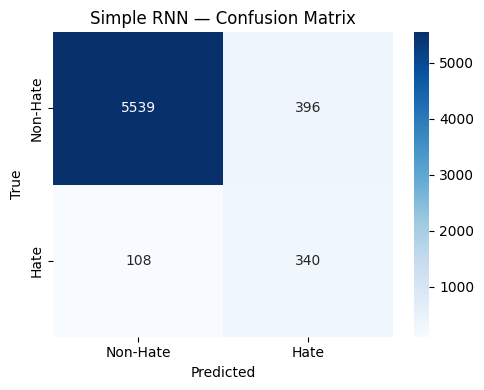

In [16]:
plot_history(hist_rnn, 'Simple RNN')
y_pred_rnn, y_proba_rnn = evaluate_model(rnn_model, X_test, y_test, 'Simple RNN')


## 8. Model 2 — LSTM with Trainable Embedding

In [17]:
def build_lstm_trainable(vocab_size, max_len, embed_dim=64):
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim),
        layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ], name='lstm_trainable')
    return model

lstm_model = build_lstm_trainable(vocab_size, MAX_LEN)
lstm_model.summary()


Model: "lstm_trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[make_early_stopping()],
    verbose=1,
)
time_lstm = time.time() - t0
print(f'\nLSTM (trainable embedding) training time: {time_lstm:.1f} s')


Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.7974 - loss: 0.4562 - val_accuracy: 0.9233 - val_loss: 0.2502
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9189 - loss: 0.2286 - val_accuracy: 0.9323 - val_loss: 0.2120
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9429 - loss: 0.1587 - val_accuracy: 0.9444 - val_loss: 0.1563
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9544 - loss: 0.1120 - val_accuracy: 0.9468 - val_loss: 0.1728
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.9650 - loss: 0.0864 - val_accuracy: 0.9229 - val_loss: 0.2426
Epoch 6/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9661 - loss: 0.0818 - val_accuracy: 0.9135 - val_loss: 0.2468
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

LSTM (trainable embedding) training time: 151.4 s


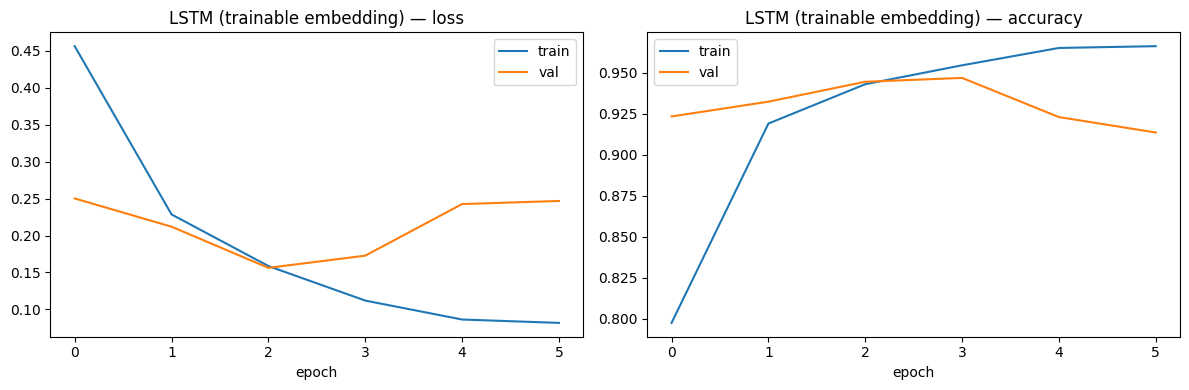


===== LSTM (trainable) =====
              precision    recall  f1-score   support

    Non-Hate      0.981     0.956     0.968      5935
        Hate      0.563     0.759     0.646       448

    accuracy                          0.942      6383
   macro avg      0.772     0.857     0.807      6383
weighted avg      0.952     0.942     0.946      6383



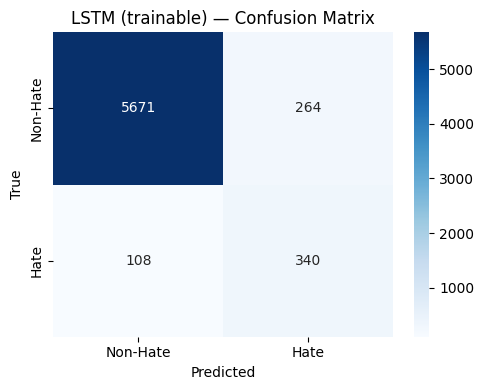

In [19]:
plot_history(hist_lstm, 'LSTM (trainable embedding)')
y_pred_lstm, y_proba_lstm = evaluate_model(lstm_model, X_test, y_test, 'LSTM (trainable)')


## 9. Model 3 — LSTM with Pretrained GloVe Embeddings

We use **GloVe (50-dim)** loaded via gensim. GloVe is a Word2Vec-family algorithm that learns word vectors from co-occurrence statistics on a huge corpus.

In [20]:
# Load pretrained GloVe via gensim
!pip install -q gensim
import gensim.downloader as api

print('Loading glove-twitter-50 (about 150 MB, takes ~1-2 min)...')
embedding_model = api.load('glove-twitter-50')   # Twitter-trained → fits our domain
print('Loaded.')

# Note: glove-twitter-50 is preferred over glove-wiki because our data IS twitter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.8 MB/s eta 0:00:00
Loading glove-twitter-50 (about 150 MB, takes ~1-2 min)...
[==================================================] 100.0% 199.5/199.5MB downloaded
Loaded.


In [21]:
# Build embedding matrix from GloVe
EMBED_DIM = 50
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))

found, missing = 0, 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        missing += 1

coverage = 100 * found / (found + missing)
print(f'Found embeddings for {found} / {found + missing} words ({coverage:.1f}% coverage)')


Found embeddings for 8966 / 9999 words (89.7% coverage)


In [22]:
def build_lstm_pretrained(vocab_size, max_len, embed_dim, embedding_matrix):
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            trainable=False,  # Freeze pretrained vectors
        ),
        layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ], name='lstm_glove')
    return model

lstm_glove = build_lstm_pretrained(vocab_size, MAX_LEN, EMBED_DIM, embedding_matrix)
lstm_glove.summary()


Model: "lstm_glove"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,553 (2.03 MB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [23]:
lstm_glove.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_glove = lstm_glove.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[make_early_stopping()],
    verbose=1,
)
time_glove = time.time() - t0
print(f'\nLSTM with GloVe training time: {time_glove:.1f} s')


Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.7823 - loss: 0.4829 - val_accuracy: 0.7819 - val_loss: 0.4541
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.8012 - loss: 0.4212 - val_accuracy: 0.7173 - val_loss: 0.5461
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.8197 - loss: 0.3970 - val_accuracy: 0.7854 - val_loss: 0.4356
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.8220 - loss: 0.3802 - val_accuracy: 0.7756 - val_loss: 0.4545
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8348 - loss: 0.3633 - val_accuracy: 0.8113 - val_loss: 0.3902
Epoch 6/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.8400 - loss: 0.3490 - val_accuracy: 0.7976 - val_loss: 0.3862
Epoch 7/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.8503 - loss: 0.3325 - val_accuracy: 0.8344 - val_loss: 0.3613
Epoch 8/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.8514 - loss: 0.3321 - 

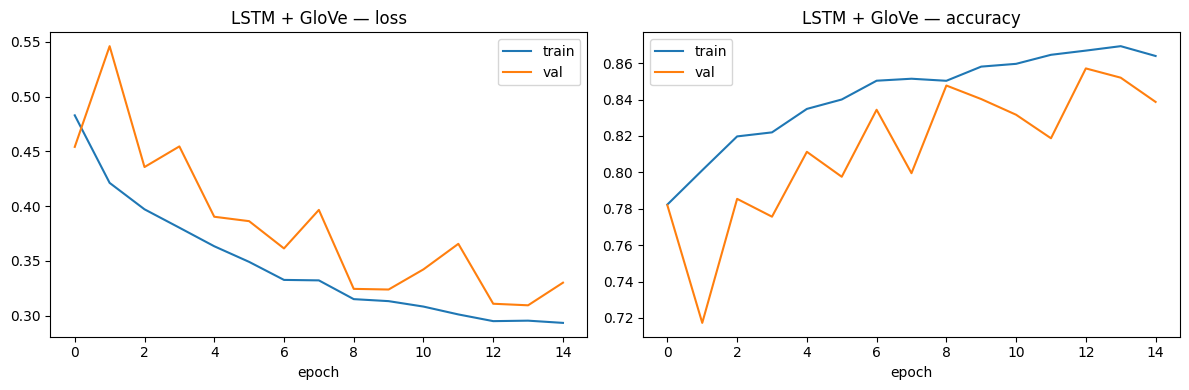


===== LSTM + GloVe =====
              precision    recall  f1-score   support

    Non-Hate      0.988     0.839     0.907      5935
        Hate      0.288     0.859     0.431       448

    accuracy                          0.841      6383
   macro avg      0.638     0.849     0.669      6383
weighted avg      0.938     0.841     0.874      6383



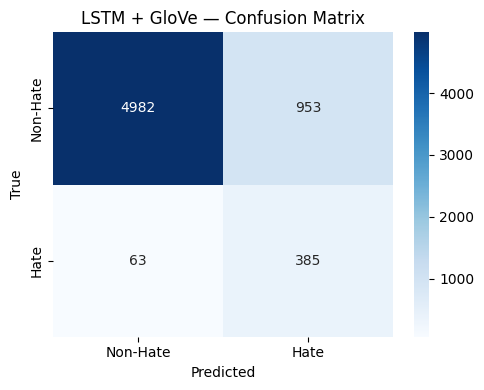

In [24]:
plot_history(hist_glove, 'LSTM + GloVe')
y_pred_glove, y_proba_glove = evaluate_model(lstm_glove, X_test, y_test, 'LSTM + GloVe')


## 10. Final Comparison

In [25]:
# Comparison table
def get_metrics(y_true, y_pred, name, train_time):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Hate)': precision_score(y_true, y_pred, pos_label=1),
        'Recall (Hate)': recall_score(y_true, y_pred, pos_label=1),
        'F1 (Hate)': f1_score(y_true, y_pred, pos_label=1),
        'Train Time (s)': round(train_time, 1),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_rnn, 'Simple RNN', time_rnn),
    get_metrics(y_test, y_pred_lstm, 'LSTM (trainable)', time_lstm),
    get_metrics(y_test, y_pred_glove, 'LSTM + GloVe', time_glove),
])
results.round(3)


,Model,Accuracy,Precision (Hate),Recall (Hate),F1 (Hate),Train Time (s)
0,Simple RNN,0.921,0.462,0.759,0.574,21.2
1,LSTM (trainable),0.942,0.563,0.759,0.646,151.4
2,LSTM + GloVe,0.841,0.288,0.859,0.431,341.4


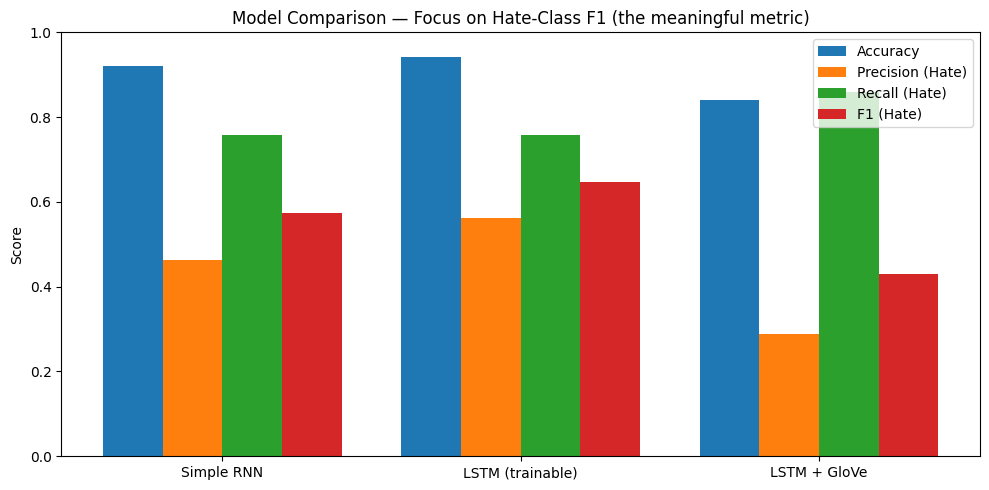


Key takeaway: With class imbalance, accuracy is misleading.
Look at F1 (Hate) — that is the metric that matters here.


In [26]:
# Visual comparison
metric_cols = ['Accuracy', 'Precision (Hate)', 'Recall (Hate)', 'F1 (Hate)']
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
width = 0.2
for i, col in enumerate(metric_cols):
    ax.bar(x + i*width, results[col], width, label=col)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results['Model'])
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Focus on Hate-Class F1 (the meaningful metric)')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('\nKey takeaway: With class imbalance, accuracy is misleading.')
print('Look at F1 (Hate) — that is the metric that matters here.')


## 11. Error Analysis

In [27]:
# Find misclassifications using the best model (by Hate F1)
best_idx = results['F1 (Hate)'].idxmax()
best_name = results.iloc[best_idx]['Model']
print(f'Best model by Hate F1: {best_name}')

# Use that model's predictions
preds_map = {
    'Simple RNN': y_pred_rnn,
    'LSTM (trainable)': y_pred_lstm,
    'LSTM + GloVe': y_pred_glove,
}
y_pred_best = preds_map[best_name]

# False negatives: model predicted non-hate, but it was hate (more dangerous)
fn_mask = (y_test == 1) & (y_pred_best == 0)
fp_mask = (y_test == 0) & (y_pred_best == 1)

print(f'\nFalse negatives (missed hate): {fn_mask.sum()}')
print(f'False positives (false alarms): {fp_mask.sum()}')

print('\n=== Sample False Negatives (model missed hate speech) ===')
fn_indices = np.where(fn_mask)[0][:3]
for idx in fn_indices:
    print(f'\nOriginal: {X_test_raw[idx]}')
    print(f'Cleaned:  {X_test_raw[idx]}')
    print(f'True: HATE | Predicted: NON-HATE')

print('\n=== Sample False Positives (model raised false alarm) ===')
fp_indices = np.where(fp_mask)[0][:3]
for idx in fp_indices:
    print(f'\nOriginal: {X_test_raw[idx]}')
    print(f'True: NON-HATE | Predicted: HATE')


Best model by Hate F1: LSTM (trainable)

False negatives (missed hate): 108
False positives (false alarms): 264

=== Sample False Negatives (model missed hate speech) ===

Original: buy book deal whitenationalist miloyiannopoulos
Cleaned:  buy book deal whitenationalist miloyiannopoulos
True: HATE | Predicted: NON-HATE

Original: waiting somebody call see anybody
Cleaned:  waiting somebody call see anybody
True: HATE | Predicted: NON-HATE

Original: surprise adam saleh
Cleaned:  surprise adam saleh
True: HATE | Predicted: NON-HATE

=== Sample False Positives (model raised false alarm) ===

Original: lol ask please
True: NON-HATE | Predicted: HATE

Original: would rather nominate racist liberal paul ryan basically uniteblue
True: NON-HATE | Predicted: HATE

Original: jalandhar say appointing honest police officer
True: NON-HATE | Predicted: HATE


**Possible reasons for errors:**

- **False negatives (missed hate):** Sarcasm, coded language, slurs not in training vocabulary, very short tweets with little context.
- **False positives (false alarms):** Tweets discussing hate speech (e.g., news articles), emotionally charged but non-hateful tweets, words that co-occur with hate but aren't inherently hateful.

**Suggested improvements:**

- More training data, especially of minority class
- Larger pretrained embeddings (GloVe-200 or BERT)
- Bidirectional LSTM to capture forward + backward context
- Attention mechanism to focus on key hate words
- Subword tokenization (BPE) to handle slurs and rare words


## 12. Bonus — Gradio GUI for Real-Time Prediction

In [28]:
# pip install gradio if not already installed
# !pip install -q gradio

import gradio as gr

# Use the best model
best_model_obj = {
    'Simple RNN': rnn_model,
    'LSTM (trainable)': lstm_model,
    'LSTM + GloVe': lstm_glove,
}[best_name]

def predict_tweet(tweet_text):
    if not tweet_text.strip():
        return 'Please enter a tweet.', None
    cleaned = clean_tweet(tweet_text)
    if not cleaned:
        return 'After cleaning, no usable text remained.', None
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    proba = float(best_model_obj.predict(padded, verbose=0).flatten()[0])
    label = 'HATE SPEECH' if proba > 0.5 else 'NOT HATE SPEECH'
    confidence = proba if proba > 0.5 else 1 - proba
    return f'{label} (confidence: {confidence:.1%})', {'Non-Hate': 1 - proba, 'Hate': proba}

demo = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(lines=3, placeholder='Enter a tweet to classify...', label='Tweet'),
    outputs=[
        gr.Textbox(label='Prediction'),
        gr.Label(label='Probabilities'),
    ],
    title=f'Hate Speech Classifier ({best_name})',
    description='Enter a tweet and the model will predict whether it contains racist/sexist hate speech.',
    examples=[
        ['I love sunny days at the park!'],
        ['Going to the market this afternoon, anyone want anything?'],
        ['You should not speak to women like that, it is unacceptable.'],
    ],
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ad28cbfbbd10fc562a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 13. Closing Notes for Your Report

What to include in your report (in your own words):

- **Dataset stats** from Section 3 (31,962 tweets, severe 93/7 imbalance)
- **Preprocessing decisions** and how you handled contractions, hashtags, etc.
- **Class imbalance handling** — class weights, why F1 over accuracy
- **Model comparison** — RNN vs LSTM vs LSTM+GloVe with concrete numbers
- **GloVe embedding coverage** (the % from Section 9)
- **Error analysis** — show 2-3 misclassifications with explanation
- **Limitations** — sarcasm, slurs not in vocab, small minority class
- **Future work** — BiLSTM, attention, larger embeddings, BERT

Good luck with the viva.
